

# **Predicting Eye Strain from Digital Device Usage Using Machine Learning**






1.	Problem Statement
With the widespread use of smartphones, computers, and other digital devices, digital eye strain has become a common issue affecting many individuals. Long screen exposure, poor viewing habits, inadequate lighting, and lack of eye protection may all contribute to eye discomfort and related symptoms.
The problem addressed in this project is to predict whether a person is likely to experience eye strain or not based on demographic information, digital device usage habits, environmental factors, and physical symptoms collected through a questionnaire.
This project applies machine learning techniques to classify respondents into two categories: eye strain and no eye strain. The goal is to better understand the factors associated with eye strain and build a predictive model that can support early identification of individuals at risk.


2. Project Aim & Objectives

  The aim of this project is to develop a machine learning model capable of predicting eye strain based on users’ digital device usage patterns and related behavioral, environmental, and physiological factors.The project seeks to analyze how variables such as screen time, device type, brightness, distance, sleep habits, and eye related symptoms contribute to the likelihood of experiencing eye strain.

**Project Objectives**

1-Data Understanding and Preparation

*   Explore and understand the structure of the dataset (243 records, 16 features).

*   Verify data quality by checking for missing values, incorrect encodings, and outliers.

*   Perform descriptive statistics to understand distributions and feature ranges.



2-Exploratory Data Analysis (EDA)

*   Visualize the distribution of demographic, behavioral, and screen‑related variables.

*   Analyze the prevalence of eye strain and identify dataset imbalance.

*   Investigate relationships between device usage habits and eye strain indicators (dryness, headache, fatigue).



3-Feature Assessment

*   Validate the encoding of categorical and ordinal features.

*   Identify the most influential factors contributing to eye strain (e.g., phone usage hours, use before sleep, break frequency).



4-Model Development

*   Prepare the dataset for machine learning (splitting, scaling, handling imbalance if needed).

*   Train and evaluate predictive models to classify users into Eye Strain vs. No Eye Strain.



5-Insights and Recommendations

*   Interpret model results to highlight key risk factors.

*   Provide actionable recommendations to reduce eye strain based on data-driven insights..

# **3. Exploratory Data Analysis(EDA):**

In [1]:
# Importing needed python libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, RobustScaler, Normalizer, MinMaxScaler
from sklearn import preprocessing
from scipy.stats import shapiro
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

In [2]:

# Read eye strain dataset to pandas dataframe and show first 10 rows
data = pd.read_csv('eye_strain_data.csv')
# Print an overview of data
data.head(10)

,age,gender,employment_status,phone_usage_hours,computer_usage_hours,use_before_sleep,break_frequency,eye_protection_usage,night_mode_usage,screen_distance,screen_brightness,eye_dryness,headache_fatigue,room_lighting,sleep_hours,eye_strain
0,1,0,0,3,1,2,0,0,1,0,0,1,1,1,1,1
1,1,0,0,2,1,2,1,2,0,0,0,1,0,2,2,0
2,1,0,0,3,0,2,3,0,1,1,0,0,0,0,3,0
3,1,0,0,2,0,2,3,2,0,0,1,1,1,0,2,1
4,1,0,0,3,0,2,3,0,0,1,0,0,1,1,1,1
5,1,0,0,3,0,2,1,0,0,0,2,1,1,1,1,1
6,1,0,0,2,0,2,2,0,0,0,0,1,2,1,1,1
7,1,0,0,3,0,1,2,0,1,1,0,1,2,0,2,0
8,1,0,0,1,2,2,3,1,1,1,1,1,1,1,2,0
9,1,0,0,2,0,2,1,2,1,1,1,1,1,1,1,0


DATA DESCRIPTIONS:

AGE: respondent age category (Ordinal); 0 = Under 18, 1 = 18–30, 2 = More than 30  
GENDER: respondent gender (Nominal); 0 = Female, 1 = Male  
EMPLOYMENT_STATUS: respondent employment status (Nominal); 0 = Student, 1 = Employee, 2 = Other  
PHONE_USAGE_HOURS: respondent daily phone usage duration (Ordinal); 0 = Less than 2 hours, 1 = 2–4 hours, 2 = 4–6 hours, 3 = More than 6 hours  
COMPUTER_USAGE_HOURS: respondent daily computer usage duration (Ordinal); 0 = Less than 2 hours, 1 = 2–4 hours, 2 = 4–6 hours, 3 = More than 6 hours  
USE_BEFORE_SLEEP: respondent usage of digital devices before sleeping (Ordinal); 0 = Never, 1 = Sometimes, 2 = Always  
BREAK_FREQUENCY: respondent frequency of taking breaks during device usage (Ordinal); 0 = No break, 1 = Once, 2 = 2–3 times, 3 = More than 3 times  
EYE_PROTECTION_USAGE: respondent usage of eye protection tools (Ordinal); 0 = Never, 1 = Sometimes, 2 = Always  
EYE_STRAIN: respondent eye strain condition (Nominal, Binary Target);  0 = No eye strain, 1 = Eye strain

In [3]:
# Show the number of rows and columns eye strain dataset
data.shape

(243, 16)

In [4]:
# Show basic information about the dataset
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   age                   243 non-null    int64
 1   gender                243 non-null    int64
 2   employment_status     243 non-null    int64
 3   phone_usage_hours     243 non-null    int64
 4   computer_usage_hours  243 non-null    int64
 5   use_before_sleep      243 non-null    int64
 6   break_frequency       243 non-null    int64
 7   eye_protection_usage  243 non-null    int64
 8   night_mode_usage      243 non-null    int64
 9   screen_distance       243 non-null    int64
 10  screen_brightness     243 non-null    int64
 11  eye_dryness           243 non-null    int64
 12  headache_fatigue      243 non-null    int64
 13  room_lighting         243 non-null    int64
 14  sleep_hours           243 non-null    int64
 15  eye_strain            243 non-null    int64
dtypes: int64

In [5]:
# Check missing values
data.isnull().sum()

,0
age,0
gender,0
employment_status,0
phone_usage_hours,0
computer_usage_hours,0
use_before_sleep,0
break_frequency,0
eye_protection_usage,0
night_mode_usage,0
screen_distance,0


The above information shows that there is no missing value in the dataset
and all the data has 243 values with types of integer.

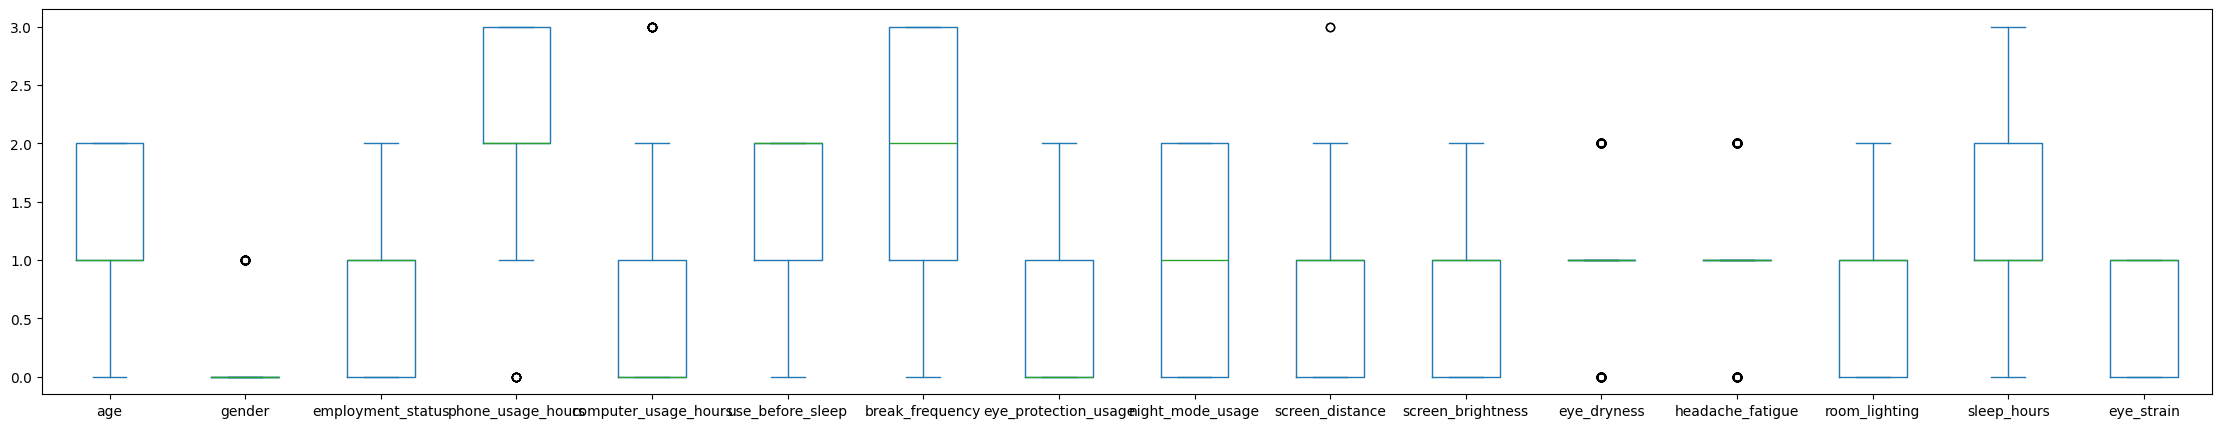

In [6]:
# We visualize the data roughly to see its general patterns by using  box plot.
# create a box plot
data.plot.box(figsize=(28,5))
plt.show()

The boxplot shows the distribution of all features, where all values fall within the expected range (0–3) based on the encoding scheme. Some points appear as outliers, but they are minimal and expected due to the categorical nature of the data. Overall, the dataset does not contain significant outliers and is considered clean.

# **AI-Assisted Data Preprocessing and Ethics Considerations .**

---



In [7]:
# --------------------------------------------
# Display unique values (Transparency)
# --------------------------------------------
for col in data.columns:
    print(col, data[col].unique())

age [1 2 0]
gender [0 1]
employment_status [0 1 2]
phone_usage_hours [3 2 1 0]
computer_usage_hours [1 0 2 3]
use_before_sleep [2 1 0]
break_frequency [0 1 3 2]
eye_protection_usage [0 2 1]
night_mode_usage [1 0 2]
screen_distance [0 1 3 2]
screen_brightness [0 1 2]
eye_dryness [1 0 2]
headache_fatigue [1 0 2]
room_lighting [1 2 0]
sleep_hours [1 2 3 0]
eye_strain [1 0]


In [8]:
# --------------------------------------------
# Validate encoding (Fairness)
# --------------------------------------------
valid_values = {
    "age": [0,1,2],
    "gender": [0,1],
    "employment_status": [0,1,2],
    "phone_usage_hours": [0,1,2,3],
    "computer_usage_hours": [0,1,2,3],
    "use_before_sleep": [0,1,2],
    "break_frequency": [0,1,2,3],
    "eye_protection_usage": [0,1,2],
    "night_mode_usage": [0,1,2],
    "screen_distance": [0,1,2,3],
    "screen_brightness": [0,1,2],
    "eye_dryness": [0,1,2],
    "headache_fatigue": [0,1,2],
    "room_lighting": [0,1,2],
    "sleep_hours": [0,1,2,3],
    "eye_strain": [0,1,2]
}

for col, valid in valid_values.items():
    invalid = data[~data[col].isin(valid)]
    if not invalid.empty:
        print(f"Column {col} has invalid values:")
        print(invalid[col].unique())


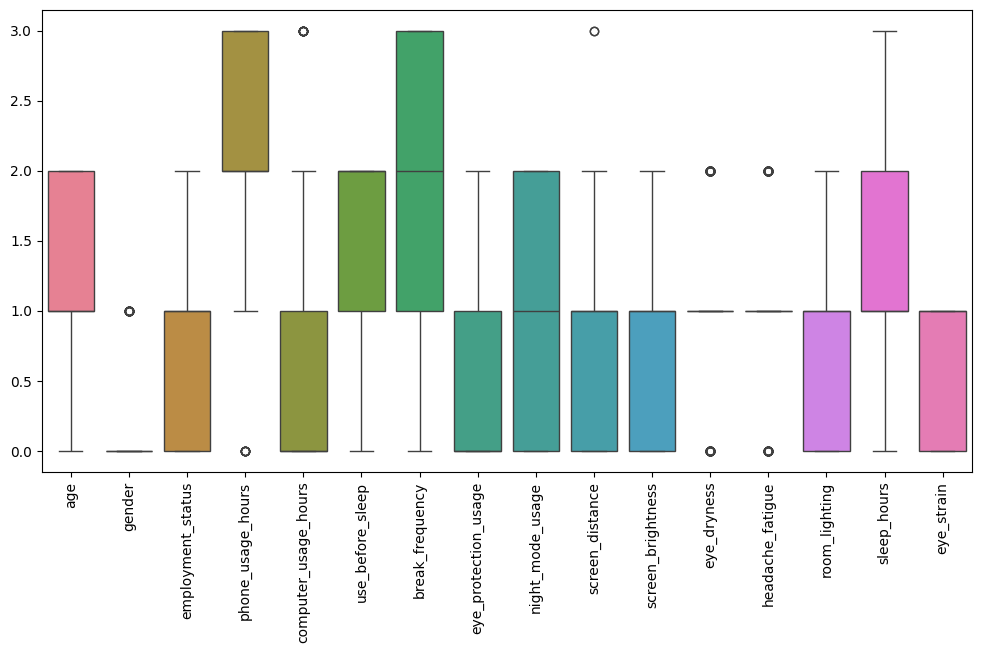

In [9]:
# --------------------------------------------
# Visualization (Outliers detection)
# --------------------------------------------
plt.figure(figsize=(12,6))
sns.boxplot(data)
plt.xticks(rotation=90)
plt.show()

# **After checking that there is no missing or outlier we continue the EDA**

In [10]:
# Show out the statistical description of your data
data.describe()

,age,gender,employment_status,phone_usage_hours,computer_usage_hours,use_before_sleep,break_frequency,eye_protection_usage,night_mode_usage,screen_distance,screen_brightness,eye_dryness,headache_fatigue,room_lighting,sleep_hours,eye_strain
count,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,1.386831,0.115226,0.658436,2.222222,0.695473,1.707819,1.995885,0.670782,0.967078,0.621399,0.798354,1.037037,1.049383,0.728395,1.353909,0.683128
std,0.573657,0.319954,0.729118,0.838140,0.898725,0.531080,1.034520,0.837308,0.765303,0.607014,0.593071,0.632020,0.594073,0.506463,0.846880,0.466218
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,2.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000
50%,1.000000,0.000000,1.000000,2.000000,0.000000,2.000000,2.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,2.000000,0.000000,1.000000,3.000000,1.000000,2.000000,3.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000
max,2.000000,1.000000,2.000000,3.000000,3.000000,2.000000,3.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,3.000000,1.000000


The describe function shows a statistical summary of all variables and they are are properly distributed and recoded. The average values indicate moderate usage of digital devices and moderate eye strain levels among participants. The minimum and maximum values confirm that the data follows the defined encoding scheme. Overall, the dataset is clean and suitable for machine learning analysis.

In [11]:
# Print out the number of data for target feature eye_strain
data["eye_strain"].value_counts()

,count
eye_strain,
1,166
0,77


# Use the following definition:
# 0/-ve (No eye strain), 1/+ve (Eye strain)

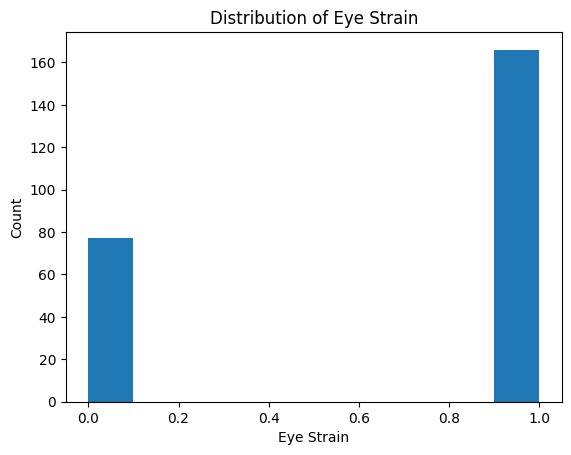

In [12]:
# Class distribution for the eye_strain target column
Eye_strin=data["eye_strain"]

# histogram plot
plt.hist(Eye_strin)
plt.xlabel("Eye Strain")
plt.ylabel("Count")
plt.title("Distribution of Eye Strain")
plt.show()

The distribution shows that most respondents suffer from eye strain, while fewer respondents do not.
This indicates that eye strain is a common issue among participants , which means that the data is imbalanced which is usually what happens with real data.

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'gender'}>,
        <Axes: title={'center': 'employment_status'}>,
        <Axes: title={'center': 'phone_usage_hours'}>],
       [<Axes: title={'center': 'computer_usage_hours'}>,
        <Axes: title={'center': 'use_before_sleep'}>,
        <Axes: title={'center': 'break_frequency'}>,
        <Axes: title={'center': 'eye_protection_usage'}>],
       [<Axes: title={'center': 'night_mode_usage'}>,
        <Axes: title={'center': 'screen_distance'}>,
        <Axes: title={'center': 'screen_brightness'}>,
        <Axes: title={'center': 'eye_dryness'}>],
       [<Axes: title={'center': 'headache_fatigue'}>,
        <Axes: title={'center': 'room_lighting'}>,
        <Axes: title={'center': 'sleep_hours'}>,
        <Axes: title={'center': 'eye_strain'}>]], dtype=object)

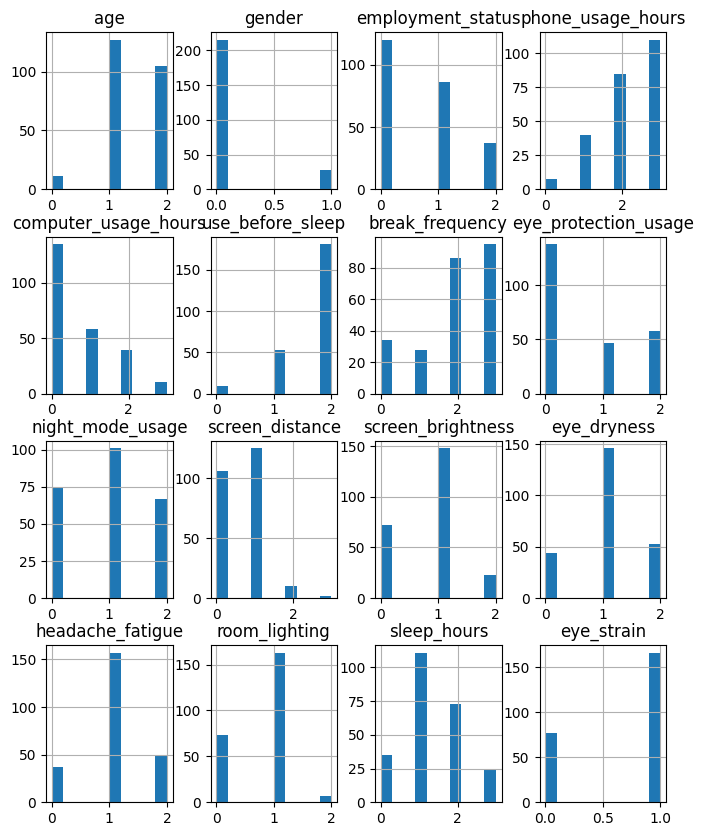

In [13]:
# Checking data distribution for all columns
data.hist(figsize=(8,10))

The plots show that most respondents are between 18–30 years old,
and there are more females than males. Most of the participants are students.
In terms of device usage, many respondents use their phones for long hours,
while computer usage is generally lower. It is also clear that most people use their devices before sleep,
which is a common habit. The frequency of taking breaks varies, but many respondents do take breaks.
Eye protection is not widely used, as most respondents do not use it regularly. For screen-related factors,
most respondents use moderate screen distance and brightness. In addition,
many respondents experience moderate eye dryness and headache or fatigue. Room lighting is mostly moderate,
and most people have average sleep hours. Overall, the results show that eye strain is common among respondents,
as a large number of them experience it.

# Bulid Models

In [14]:
# Setting features (X) and target (y)
# NOTE: using column names instead of positional indices (.iloc) for robustness—
# this avoids silently selecting the wrong column if the CSV's columns ever change order,
# and explicitly drops 'ID', which is just a row identifier and not a real predictive feature.
x = data.drop(columns=['eye_strain', 'ID'], errors='ignore').values
y = data['eye_strain'].values

In [15]:
# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

# Build **LogisticRegression** Model


Logistic Regression Default Model
Training Accuracy: 0.7705882352941177
Test Accuracy: 0.7671232876712328
Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.48      0.56        23
           1       0.79      0.90      0.84        50

    accuracy                           0.77        73
   macro avg       0.74      0.69      0.70        73
weighted avg       0.76      0.77      0.75        73



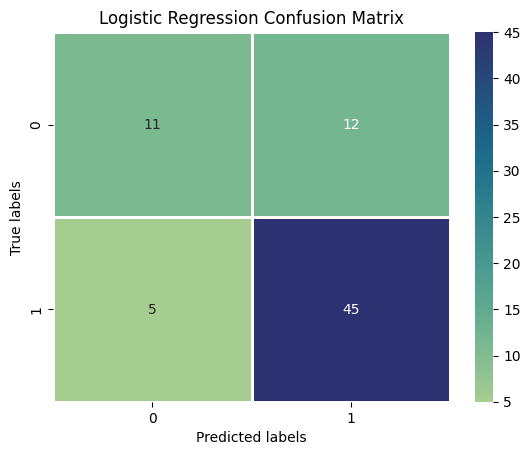

In [16]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

lr_train_pred = lr.predict(X_train)
lr_test_pred = lr.predict(X_test)

print("Logistic Regression Default Model")
print("Training Accuracy:", accuracy_score(y_train, lr_train_pred))
print("Test Accuracy:", accuracy_score(y_test, lr_test_pred))

print("Classification Report:")
print(classification_report(y_test, lr_test_pred))

lr_cm = confusion_matrix(y_test, lr_test_pred)
sns.heatmap(lr_cm, annot=True, cmap='crest', fmt="g", linewidth=2)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


The model shows no overfitting or underfitting.

Training and test accuracies are very close, indicating good generalization.


In [17]:
# Split data into train+validation set and test set
X_trainval, X_test, y_trainval, y_test = train_test_split(x, y, test_size = 0.3, random_state=42, stratify=y)

In [18]:
# Grid Search with Cross-Validation for Logistic Regression

best_score = 0

for C in [0.01, 0.1, 1, 10, 100]:
    for solver in ['liblinear']:

        # Initialize Logistic Regression with current parameters
        model = LogisticRegression(C=C, solver=solver)

        # Perform cross-validation
        scores = cross_val_score(model, X_trainval, y_trainval, cv=5)

        # Compute mean cross-validation accuracy
        score = np.mean(scores)

        # If we got a better score, store the score and parameters
        if score > best_score:
            best_score = score
            best_params_lr = {'C': C, 'solver': solver}

print(f"Best Logistic Regression score: {best_score:.4f}")
print(f"Best Logistic Regression parameters: {best_params_lr}")

Best Logistic Regression score: 0.7529
Best Logistic Regression parameters: {'C': 1, 'solver': 'liblinear'}


Logistic Regression After Tuning
Training Accuracy: 0.7705882352941177
Test Accuracy: 0.7671232876712328
Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.48      0.56        23
           1       0.79      0.90      0.84        50

    accuracy                           0.77        73
   macro avg       0.74      0.69      0.70        73
weighted avg       0.76      0.77      0.75        73

Confusion Matrix:


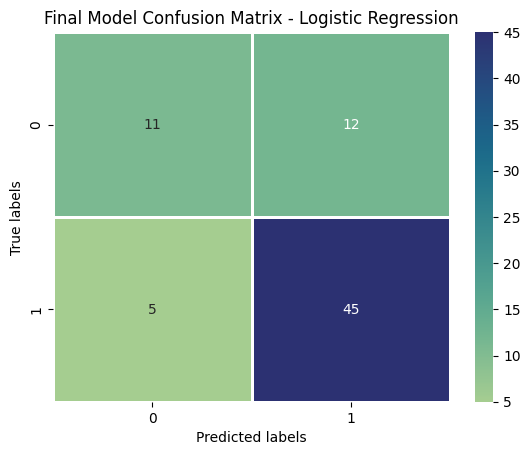

In [19]:
# Rebuild Logistic Regression model using best parameters
lr_tuned = LogisticRegression(C=1,solver="liblinear")
lr_tuned.fit(X_trainval, y_trainval)

lr_tuned_train_pred = lr_tuned.predict(X_trainval)
lr_tuned_test_pred = lr_tuned.predict(X_test)

print("Logistic Regression After Tuning")
print("Training Accuracy:", accuracy_score(y_trainval, lr_tuned_train_pred))
print("Test Accuracy:", accuracy_score(y_test, lr_tuned_test_pred))

print("Classification Report:")
print(classification_report(y_test, lr_tuned_test_pred))

print("Confusion Matrix:")
cm=confusion_matrix(y_test, lr_tuned_test_pred)

sns.heatmap(cm, annot=True, cmap='crest', fmt="g", linewidth=2)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Final Model Confusion Matrix - Logistic Regression')
plt.show()

No overfitting or underfitting detected.

The tuned model remains stable with similar training and test performance.


# Decision Tree


Decision Tree Default Model
Training Accuracy: 1.0
Test Accuracy: 0.6712328767123288
Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.39      0.43        23
           1       0.74      0.80      0.77        50

    accuracy                           0.67        73
   macro avg       0.61      0.60      0.60        73
weighted avg       0.66      0.67      0.66        73



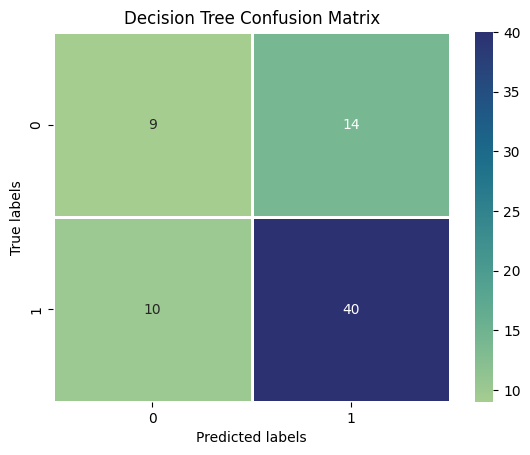

In [20]:
# Decision Tree model
dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X_train, y_train)

dt_train_pred = dt.predict(X_train)
dt_test_pred = dt.predict(X_test)

print("Decision Tree Default Model")
print("Training Accuracy:", accuracy_score(y_train, dt_train_pred))
print("Test Accuracy:", accuracy_score(y_test, dt_test_pred))

print("Classification Report:")
print(classification_report(y_test, dt_test_pred))

dt_cm = confusion_matrix(y_test, dt_test_pred)
sns.heatmap(dt_cm, annot=True, cmap='crest', fmt="g", linewidth=2)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Decision Tree Confusion Matrix")
plt.show()

The model is heavily overfitting.

Training accuracy is 100% while test accuracy is much lower.


## 1. Using Min Max Scaler



In [21]:
# Apply MinMaxScaler to the worst model: Decision Tree
mm_scaler = preprocessing.MinMaxScaler()
X_scaled = mm_scaler.fit_transform(x)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

dt_scaled = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_scaled.fit(X_train_s, y_train_s)

dt_scaled_train_pred = dt_scaled.predict(X_train_s)
dt_scaled_test_pred = dt_scaled.predict(X_test_s)

print("Decision Tree After Scaling")
print("Training Accuracy:", accuracy_score(y_train_s, dt_scaled_train_pred))
print("Test Accuracy:", accuracy_score(y_test_s, dt_scaled_test_pred))

print(classification_report(y_test_s, dt_scaled_test_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test_s, dt_scaled_test_pred))

Decision Tree After Scaling
Training Accuracy: 1.0
Test Accuracy: 0.6712328767123288
              precision    recall  f1-score   support

           0       0.47      0.39      0.43        23
           1       0.74      0.80      0.77        50

    accuracy                           0.67        73
   macro avg       0.61      0.60      0.60        73
weighted avg       0.66      0.67      0.66        73

Confusion Matrix:
[[ 9 14]
 [10 40]]


Still overfitting.

Scaling does not affect Decision Trees, so the issue remains.


## 2. Using Standard Scaler


In [22]:
from sklearn import preprocessing

std_scaler = preprocessing.StandardScaler()
X_std = std_scaler.fit_transform(x)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_std, y, test_size=0.3, random_state=42, stratify=y
)

dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X_train2, y_train2)

y_train_pred2 = dt.predict(X_train2)
y_pred2 = dt.predict(X_test2)

print('Training Accuracy (StandardScaler): ', accuracy_score(y_train2, y_train_pred2))
print('Test Accuracy (StandardScaler): ', accuracy_score(y_test2, y_pred2))
print("Classification Report (StandardScaler):")
print(classification_report(y_test2, y_pred2))

print("Confusion Matrix:")
print(confusion_matrix(y_test2, y_pred2))

Training Accuracy (StandardScaler):  1.0
Test Accuracy (StandardScaler):  0.6712328767123288
Classification Report (StandardScaler):
              precision    recall  f1-score   support

           0       0.47      0.39      0.43        23
           1       0.74      0.80      0.77        50

    accuracy                           0.67        73
   macro avg       0.61      0.60      0.60        73
weighted avg       0.66      0.67      0.66        73

Confusion Matrix:
[[ 9 14]
 [10 40]]


 Overfitting persists.

Decision Trees are not impacted by StandardScaler.


## 3. Using RobustScaler  

In [23]:
rb_scaler = preprocessing.RobustScaler()
X_rb = rb_scaler.fit_transform(x)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_rb, y, test_size=0.3, random_state=42, stratify=y
)

dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X_train2, y_train2)

y_train_pred2 = dt.predict(X_train2)
y_pred2 = dt.predict(X_test2)

print('Training Accuracy (RobustScaler): ', accuracy_score(y_train2, y_train_pred2))
print('Test Accuracy (RobustScaler): ', accuracy_score(y_test2, y_pred2))
print("Classification Report (RobustScaler):")
print(classification_report(y_test2, y_pred2))

Training Accuracy (RobustScaler):  1.0
Test Accuracy (RobustScaler):  0.6712328767123288
Classification Report (RobustScaler):
              precision    recall  f1-score   support

           0       0.47      0.39      0.43        23
           1       0.74      0.80      0.77        50

    accuracy                           0.67        73
   macro avg       0.61      0.60      0.60        73
weighted avg       0.66      0.67      0.66        73



 The model continues to overfit.

 Scaling does not solve overfitting for tree-based models.


## 4. Using Normalizer  

In [24]:
norm_scaler = preprocessing.Normalizer()
X_norm = norm_scaler.fit_transform(x)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_norm, y, test_size=0.3, random_state=42, stratify=y
)

dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X_train2, y_train2)

y_train_pred2 = dt.predict(X_train2)
y_pred2 = dt.predict(X_test2)

print('Training Accuracy (Normalizer): ', accuracy_score(y_train2, y_train_pred2))
print('Test Accuracy (Normalizer): ', accuracy_score(y_test2, y_pred2))
print("Classification Report (Normalizer):")
print(classification_report(y_test2, y_pred2))

Training Accuracy (Normalizer):  1.0
Test Accuracy (Normalizer):  0.7123287671232876
Classification Report (Normalizer):
              precision    recall  f1-score   support

           0       0.56      0.43      0.49        23
           1       0.76      0.84      0.80        50

    accuracy                           0.71        73
   macro avg       0.66      0.64      0.64        73
weighted avg       0.70      0.71      0.70        73



Slight improvement but still overfitting.

Training accuracy remains 100%, indicating poor generalization.


In [25]:
# Grid Search with Cross-Validation for Decision Tree

best_score = 0

for criterion in ['gini', 'entropy']:
    for max_depth in [2, 3, 4, 5, 6, 7]:
        for min_samples_split in [2, 5, 10]:

            # Initialize Decision Tree with current parameters
            model = DecisionTreeClassifier(
                criterion=criterion,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                random_state=42
            )

            # Perform cross-validation
            scores = cross_val_score(model, X_trainval, y_trainval, cv=5)

            # Compute mean cross-validation accuracy
            score = np.mean(scores)

            # If we got a better score, store the score and parameters
            if score > best_score:
                best_score = score
                best_params_dt = {
                    'criterion': criterion,
                    'max_depth': max_depth,
                    'min_samples_split': min_samples_split
                }

print(f"Best Decision Tree score: {best_score:.4f}")
print(f"Best Decision Tree parameters: {best_params_dt}")

Best Decision Tree score: 0.7706
Best Decision Tree parameters: {'criterion': 'entropy', 'max_depth': 2, 'min_samples_split': 2}


In [26]:
# Rebuild Decision Tree model using best parameters
dt_tuned = DecisionTreeClassifier(criterion=best_params_dt['criterion'], max_depth=best_params_dt['max_depth'],
    min_samples_split=best_params_dt['min_samples_split'],random_state=42)

dt_tuned.fit(X_trainval, y_trainval)

dt_tuned_train_pred = dt_tuned.predict(X_trainval)
dt_tuned_test_pred = dt_tuned.predict(X_test)

print("Decision Tree After Tuning")
print("Training Accuracy:", accuracy_score(y_trainval, dt_tuned_train_pred))
print("Test Accuracy:", accuracy_score(y_test, dt_tuned_test_pred))

print("Classification Report:")
print(classification_report(y_test, dt_tuned_test_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, dt_tuned_test_pred))

Decision Tree After Tuning
Training Accuracy: 0.7705882352941177
Test Accuracy: 0.7671232876712328
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.35      0.48        23
           1       0.76      0.96      0.85        50

    accuracy                           0.77        73
   macro avg       0.78      0.65      0.67        73
weighted avg       0.77      0.77      0.73        73

Confusion Matrix:
[[ 8 15]
 [ 2 48]]


 The model is no longer overfitting.

Reducing max_depth improved generalization and balanced performance.


# Random Forest


Random Forest Default Model
Training Accuracy: 1.0
Test Accuracy: 0.7397260273972602
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.35      0.46        23
           1       0.75      0.92      0.83        50

    accuracy                           0.74        73
   macro avg       0.71      0.63      0.64        73
weighted avg       0.73      0.74      0.71        73



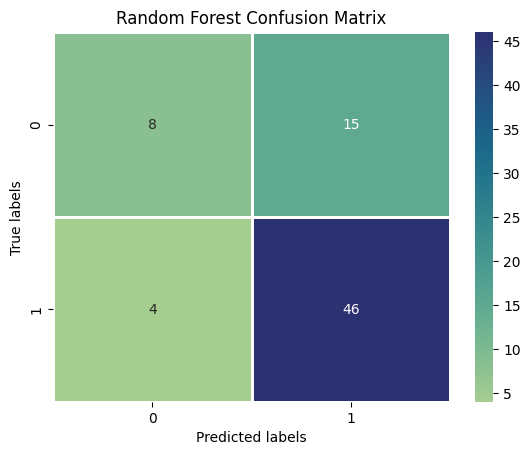

In [27]:
rf = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=42)
rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)

print("Random Forest Default Model")
print("Training Accuracy:", accuracy_score(y_train, rf_train_pred))
print("Test Accuracy:", accuracy_score(y_test, rf_test_pred))

print("Classification Report:")
print(classification_report(y_test, rf_test_pred))

rf_cm = confusion_matrix(y_test, rf_test_pred)
sns.heatmap(rf_cm, annot=True, cmap='crest', fmt="g", linewidth=2)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Random Forest Confusion Matrix")
plt.show()

The model is overfitting.
 Training accuracy is 100% while test accuracy is noticeably lower,
 indicating that the model memorized the training data instead of generalizing well.


In [28]:
# Grid Search with Cross-Validation for Random Forest

best_score = 0

for n_estimators in [50, 100, 150]:
    for criterion in ['gini', 'entropy']:
        for max_depth in [2, 3, 4, 5, 6, 7]:

            # Initialize Random Forest with current parameters
            model = RandomForestClassifier(
                n_estimators=n_estimators,
                criterion=criterion,
                max_depth=max_depth,
                random_state=42
            )

            # Perform cross-validation
            scores = cross_val_score(model, X_trainval, y_trainval, cv=5)

            # Compute mean cross-validation accuracy
            score = np.mean(scores)

            # If we got a better score, store the score and parameters
            if score > best_score:
                best_score = score
                best_params_rf = {
                    'n_estimators': n_estimators,
                    'criterion': criterion,
                    'max_depth': max_depth
                }

print(f"Best Random Forest score: {best_score:.4f}")
print(f"Best Random Forest parameters: {best_params_rf}")

Best Random Forest score: 0.7765
Best Random Forest parameters: {'n_estimators': 50, 'criterion': 'gini', 'max_depth': 3}


In [29]:
# Rebuild Random Forest model using best parameters
rf_tuned = RandomForestClassifier(n_estimators=best_params_rf['n_estimators'], criterion=best_params_rf['criterion'],
    max_depth=best_params_rf['max_depth'],random_state=42)

rf_tuned.fit(X_trainval, y_trainval)

rf_tuned_train_pred = rf_tuned.predict(X_trainval)
rf_tuned_test_pred = rf_tuned.predict(X_test)

print("Random Forest After Tuning")
print("Training Accuracy:", accuracy_score(y_trainval, rf_tuned_train_pred))
print("Test Accuracy:", accuracy_score(y_test, rf_tuned_test_pred))

print("Classification Report:")
print(classification_report(y_test, rf_tuned_test_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_tuned_test_pred))

Random Forest After Tuning
Training Accuracy: 0.7941176470588235
Test Accuracy: 0.7534246575342466
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.30      0.44        23
           1       0.75      0.96      0.84        50

    accuracy                           0.75        73
   macro avg       0.76      0.63      0.64        73
weighted avg       0.76      0.75      0.71        73

Confusion Matrix:
[[ 7 16]
 [ 2 48]]


The tuned model shows improved generalization.
 Reducing tree depth or increasing min_samples_leaf helps reduce overfitting.


#**Conclusion**

The project successfully demonstrated the use of machine learning techniques to predict digital eye strain based on users’ device‑usage habits, environmental conditions, and reported symptoms. After validating the dataset’s quality, three models Logistic Regression, Decision Tree, and Random Forest were trained and evaluated, with Logistic Regression and the tuned Decision Tree achieving the highest testing accuracy. Parameter tuning played a key role in reducing overfitting and improving the generalization performance of both the Decision Tree and Random Forest models.